In [10]:
import torch
from tqdm import tqdm
import numpy as np
import cv2
import shap  # Ensure shap is imported
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM, ScoreCAM, LayerCAM, EigenCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.models as models
import torch.nn as nn
import torchxrayvision as xrv

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from util.PNGDatasetNormalized import PNGFolderDataset

In [4]:
class XRVCorrectionDataset(torch.utils.data.Dataset):
    """
    Wraps standard XRV datasets (range -1024 to 1024) and 
    rescales them to [0, 1] to match PNGFolderDataset.
    Exposes essential attributes for MergeDataset.
    """
    def __init__(self, dataset):
        self.dataset = dataset
        if hasattr(dataset, 'csv'): self.csv = dataset.csv
        if hasattr(dataset, 'pathologies'): self.pathologies = dataset.pathologies
        if hasattr(dataset, 'labels'): self.labels = dataset.labels 
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img = sample['img']
        # Rescale [-1024, 1024] -> [0, 1]
        img = (img + 1024) / 2048.0
        img = np.clip(img, 0, 1)
        if img.ndim == 2: img = np.expand_dims(img, 0)
        sample['img'] = img
        return sample

In [6]:
def find_confusion_matrix_indices(dataset, model, target_class="Cardiomegaly", threshold=0.5, limit=5, max_scan=2000):
    """
    Scans the dataset to find indices for TP, TN, FP, FN.
    FIXED: Now dynamically handles 'target_class' for numeric columns (Edema, Consolidation, etc.)
    instead of being hardcoded to 'Cardiomegaly'.
    """
    
    results = {
        'TP': [], # True Positive
        'TN': [], # True Negative
        'FP': [], # False Positive (Type I Error)
        'FN': []  # False Negative (Type II Error)
    }
    
    model.eval()
    device = next(model.parameters()).device
    
    print(f"Scanning up to {max_scan} images to find {limit} examples per category for '{target_class}'...")
    
    if not hasattr(dataset, 'csv'):
        print("Error: Dataset does not have a .csv attribute.")
        return results
        
    if target_class in dataset.csv.columns:
        col_name = target_class
    elif 'Finding Labels' in dataset.csv.columns:
        col_name = 'Finding Labels'
    elif 'Cardiomegaly' in dataset.csv.columns:
        col_name = 'Cardiomegaly'
    else:
        print(f"Error: Could not find '{target_class}' or 'Finding Labels' column.")
        return results
    
    print(f"Using column: '{col_name}' for Ground Truth.")

    for index in tqdm(range(len(dataset))):
        if index >= max_scan:
            break
            
        if all(len(v) >= limit for v in results.values()):
            print("Found enough examples for all categories!")
            break

        label_val = dataset.csv.iloc[index][col_name]
        
        if col_name == target_class:
            if pd.isna(label_val): continue
            gt = int(label_val)
            
        else:
            if isinstance(target_class, list):
                gt = 1 if any(t in str(label_val) for t in target_class) else 0
            else:
                gt = 1 if target_class in str(label_val) else 0

        try:
            sample = dataset[index]
            img_xrv = sample['img']
            
            img_norm = (img_xrv - img_xrv.min()) / (img_xrv.max() - img_xrv.min())
            if img_norm.ndim == 2: img_norm = np.expand_dims(img_norm, axis=0)
            
            input_tensor = torch.from_numpy(img_norm).unsqueeze(0).repeat(1, 3, 1, 1).float().to(device)

            with torch.no_grad():
                output = model(input_tensor)
                prob = torch.sigmoid(output).item()
            
            pred = 1 if prob > threshold else 0
            
            if gt == 1 and pred == 1:
                if len(results['TP']) < limit: results['TP'].append(index)
            elif gt == 0 and pred == 0:
                if len(results['TN']) < limit: results['TN'].append(index)
            elif gt == 0 and pred == 1:
                if len(results['FP']) < limit: results['FP'].append(index)
            elif gt == 1 and pred == 0:
                if len(results['FN']) < limit: results['FN'].append(index)

        except Exception as e:
            continue

    # Summary Print
    print("\n--- Scanning Complete ---")
    print(f"TP (True Pos):  {results['TP']}")
    print(f"TN (True Neg):  {results['TN']}")
    print(f"FP (False Pos): {results['FP']}")
    print(f"FN (False Neg): {results['FN']}")
    
    return results

Initializing SHAP Explainer...
Scanning up to 2000 images to find 10 examples per category for 'Cardiomegaly'...
Using column: 'Finding Labels' for Ground Truth.


  9%|▊         | 958/11061 [00:08<01:24, 119.48it/s]


Found enough examples for all categories!

--- Scanning Complete ---
TP (True Pos):  [0, 30, 53, 100, 248, 267, 426, 479, 559, 705]
TN (True Neg):  [2, 3, 5, 6, 8, 9, 10, 11, 12, 13]
FP (False Pos): [48, 50, 249, 265, 313, 399, 412, 620, 721, 957]
FN (False Neg): [1, 4, 7, 21, 27, 28, 29, 31, 32, 37]
Target Index: 426
Generating CAMs...
-> Grad-CAM done.


100%|██████████| 64/64 [00:01<00:00, 41.19it/s]


-> Score-CAM done.
-> Layer-CAM done.
-> Eigen-CAM done.
Generating SHAP...
-> SHAP done.


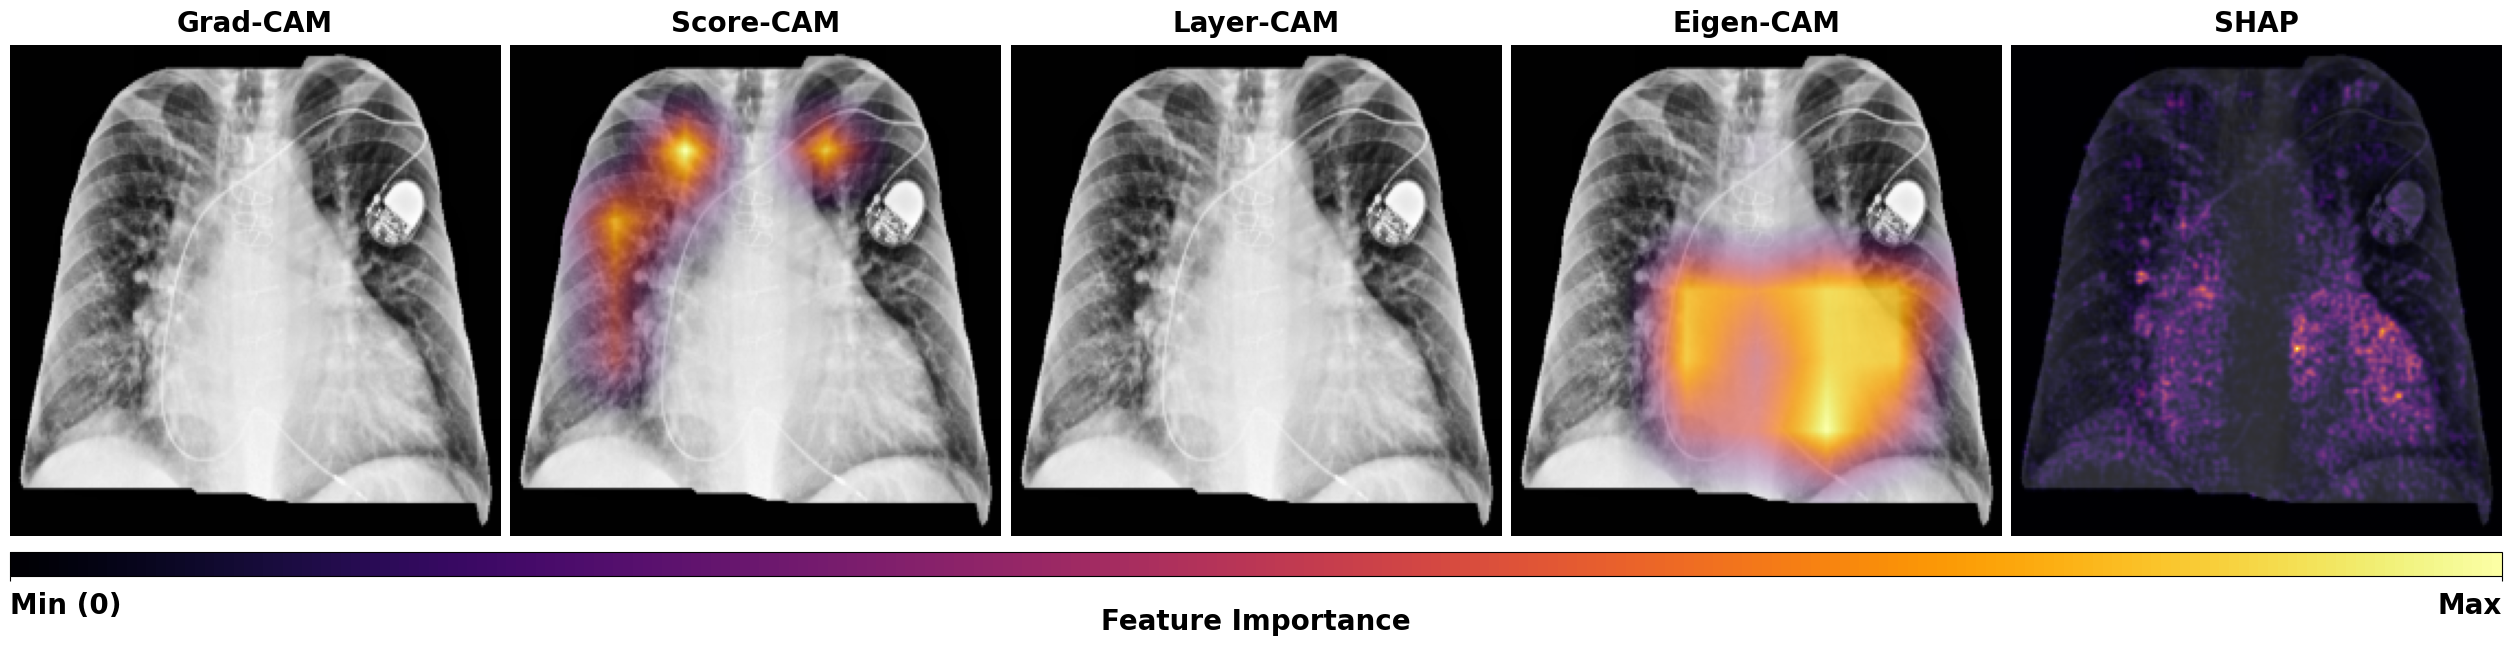

In [ ]:
def reshape_transform(tensor):
    # Standard Swin-B output: (B, H, W, C) -> Permute to (B, C, H, W)
    if tensor.ndim == 4:
        return tensor.permute(0, 3, 1, 2)
    return tensor

# 0. Setup Model & Device
weights = models.Swin_B_Weights.IMAGENET1K_V1
model = models.swin_b(weights=weights)
model.head = nn.Linear(model.head.in_features, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = "/home/varrel/image_model_dict/final/fixed_swinb_cardiomegaly_model_epoch5.pth"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

# 1. Setup Data
# WARNING: Re-initializing the dataset here might shuffle indices if unique_patients=False isn't deterministic.
# If you see "Wrong Image" (image doesn't match label), this is why.
d_nih_raw = xrv.datasets.NIH_Dataset(
    imgpath="/home/varrel/imaging/all_images/NIH_dataset/images_all/preprocess7",
    csvpath="/home/varrel/GitHub/CXR-Analysis/final_csv/nih_test_split_xrv.csv",
    views=["PA","AP"], unique_patients=False)

# Assuming XRVCorrectionDataset is defined elsewhere
d_nih_test = XRVCorrectionDataset(d_nih_raw)

# --- 1.5 RE-INITIALIZE EXPLAINER (THE FIX) ---
# We need a small batch of background images to initialize the explainer.
# We'll grab 5-10 random images from the dataset.
print("Initializing SHAP Explainer...")
background_indices = np.random.choice(len(d_nih_test), 10, replace=False)
background_images = []

for i in background_indices:
    sample_bg = d_nih_test[i]
    img_bg = sample_bg['img']
    # Normalize [0,1]
    img_bg = (img_bg - img_bg.min()) / (img_bg.max() - img_bg.min())
    img_bg_tensor = torch.from_numpy(img_bg).float()
    if img_bg_tensor.dim() == 2: img_bg_tensor = img_bg_tensor.unsqueeze(0)
    if img_bg_tensor.shape[0] == 1: img_bg_tensor = img_bg_tensor.repeat(3, 1, 1)
    background_images.append(img_bg_tensor)

background_batch = torch.stack(background_images).to(device)

# Re-create the explainer with the CURRENT model
explainer = shap.GradientExplainer(model, background_batch)
# ---------------------------------------------

# Get Target Image
# Make sure 'find_confusion_matrix_indices' is available or imported
indices_dict = find_confusion_matrix_indices(d_nih_test, model, threshold=0.587, limit=10)
target_index = indices_dict['TP'][6] 
print(f"Target Index: {target_index}")

sample = d_nih_test[target_index]
img_xrv = sample['img']

# Normalize Image
img_norm = (img_xrv - img_xrv.min()) / (img_xrv.max() - img_xrv.min())
if img_norm.ndim == 2: img_norm = np.expand_dims(img_norm, axis=0)
rgb_img = np.repeat(img_norm.transpose(1, 2, 0), 3, axis=2)
input_tensor = torch.from_numpy(img_norm).unsqueeze(0).repeat(1, 3, 1, 1).float().to(device)

# --- PREPARE MASK ---
norm_image_uint8 = (img_norm[0] * 255).astype(np.uint8)
_, binary_mask = cv2.threshold(norm_image_uint8, 15, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    filled_mask = np.zeros_like(binary_mask)
    cv2.drawContours(filled_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    mask = filled_mask.astype(np.float32) / 255.0
else:
    mask = np.ones_like(img_norm[0])

# 2. Define CAM Methods
target_layers = [model.norm]
targets = [BinaryClassifierOutputTarget(0)]

cam_methods = {
    "Grad-CAM": GradCAM,
    "Score-CAM": ScoreCAM,
    "Layer-CAM": LayerCAM,
    "Eigen-CAM": EigenCAM
}

results = {}

print("Generating CAMs...")

for name, method_class in cam_methods.items():
    try:
        cam = method_class(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        
        # Apply Mask & Normalize
        masked_cam = grayscale_cam * mask
        masked_cam = masked_cam - masked_cam.min()
        if masked_cam.max() > 0:
            masked_cam = masked_cam / masked_cam.max()
            
        # Create Overlay (Standard heatmap)
        background_weight = 0.3
        cmap = plt.get_cmap('inferno')
        cam_heatmap = cmap(masked_cam)[:, :, :3]

        visualization = (background_weight * rgb_img * (1 - masked_cam[:, :, np.newaxis])) + \
                (cam_heatmap * masked_cam[:, :, np.newaxis])
        visualization = np.clip(visualization, 0, 1)

        results[name] = visualization
        print(f"-> {name} done.")
        
    except Exception as e:
        print(f"Error generating {name}: {e}")
        results[name] = np.zeros_like(rgb_img)

# --- 2.5 ADD SHAP (Red & Smoothed) ---
from scipy.ndimage import gaussian_filter # Import needed here
print("Generating SHAP...")
try:
    # 1. Compute SHAP (Using the FRESH explainer)
    shap_values = explainer.shap_values(input_tensor)
    
    # 2. Handle Dimensions
    sv = shap_values
    if isinstance(sv, list): sv = sv[0]
    sv = np.squeeze(sv)
    if sv.ndim == 3 and sv.shape[0] == 3: 
        sv = np.transpose(sv, (1, 2, 0))
    if sv.ndim == 3:
        sv = np.sum(sv, axis=2)

    # 3. Masking
    mask_resized = mask 
    if mask.shape != sv.shape:
        mask_resized = cv2.resize(mask, (sv.shape[1], sv.shape[0]))
        
    sv_masked = sv * mask_resized
    
    # 4. CLIP NEGATIVES (Positive Only)
    sv_masked = np.maximum(sv_masked, 0)
    
    # 5. GAUSSIAN SMOOTHING (Sigma=1)
    sv_masked = gaussian_filter(sv_masked, sigma=1)
    
    # 6. Normalize [0, 1]
    if sv_masked.max() > 0:
        sv_norm = (sv_masked - sv_masked.min()) / (sv_masked.max() - sv_masked.min())
    else:
        sv_norm = sv_masked
        
    # 7. Create MANUAL RED Overlay
    cmap = plt.get_cmap('inferno')
    shap_heatmap = cmap(sv_norm)[:, :, :3]
    
    alpha = 0.8  
    shap_viz = (1 - alpha) * rgb_img + alpha * shap_heatmap
    shap_viz = np.clip(shap_viz, 0, 1)
    
    results["SHAP"] = shap_viz
    print("-> SHAP done.")

except Exception as e:
    print(f"Error generating SHAP: {e}")
    # Print full traceback to debug if needed
    import traceback
    traceback.print_exc()
    results["SHAP"] = np.zeros_like(rgb_img)

# 3. Visualize
# 1. Create figure with constrained_layout to handle tight spacing automatically
fig, axes = plt.subplots(1, 5, figsize=(25, 8), constrained_layout=True)

# 2. Plot images with zero padding between them
for ax, (name, viz) in zip(axes, results.items()):
    ax.imshow(viz)
    ax.set_title(name, fontsize=20, fontweight='bold', pad=10)
    ax.axis('off')

# 3. Create the colorbar
# We use 'ax=axes' to tell matplotlib to span the colorbar across the entire array of axes
sm = plt.cm.ScalarMappable(cmap='inferno', norm=plt.Normalize(vmin=0, vmax=1))
sm._A = []

# 'shrink=1.0' ensures it spans the full width of the subplots
# 'pad=0.02' reduces the gap between the images and the bar
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', location='bottom', 
                    aspect=100, shrink=1.0, pad=0.02)

# 4. Style the Legend
cbar.set_ticks([0, 1])
cbar.set_ticklabels([])

# 2. Manually add text at the edges of the colorbar axis (cbar.ax)
# (0, -0.5) is bottom-left, (1, -0.5) is bottom-right in axis coordinates
cbar.ax.text(0, -0.6, 'Min (0)', 
             va='top', ha='left', 
             fontsize=20, fontweight='bold', transform=cbar.ax.transAxes)

cbar.ax.text(1, -0.6, 'Max', 
             va='top', ha='right', 
             fontsize=20, fontweight='bold', transform=cbar.ax.transAxes)

cbar.set_label('Feature Importance', 
               size=20, fontweight='bold', labelpad=15)

# Optional: Further force the spacing between subplots to be nearly zero
plt.subplots_adjust(wspace=0.01) 

plt.savefig('cam_comparison2.png', dpi=300, bbox_inches='tight')
plt.show()

Saving standalone colorbar...


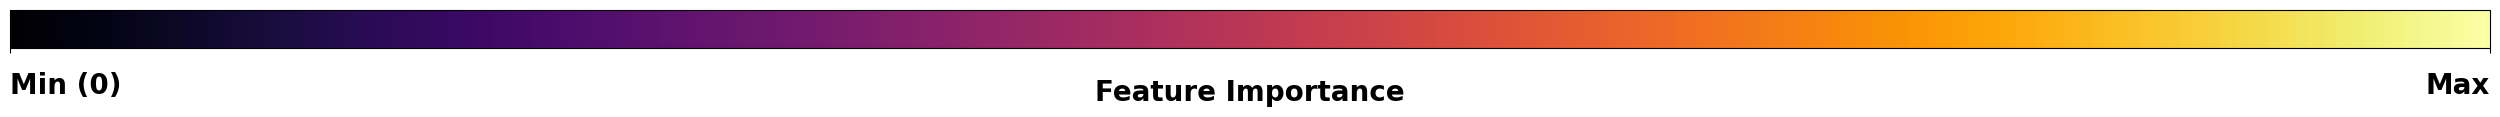

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Create a wide, short figure specifically for the colorbar
fig, ax = plt.subplots(figsize=(32, 0.5))

# 2. Define the Colormap (I used 'inferno' based on your previous code)
cmap = plt.get_cmap('inferno')
norm = mcolors.Normalize(vmin=0, vmax=1)

# Create a "dummy" ScalarMappable to feed into the colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

# 3. Draw the colorbar into the specific axis (cax=ax)
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')

# 4. Apply your exact styling
cbar.set_ticks([0, 1])
cbar.set_ticklabels([])

# Add text at the edges
cbar.ax.text(0, -0.6, 'Min (0)', 
             va='top', ha='left', 
             fontsize=20, fontweight='bold', transform=cbar.ax.transAxes)

cbar.ax.text(1, -0.6, 'Max', 
             va='top', ha='right', 
             fontsize=20, fontweight='bold', transform=cbar.ax.transAxes)

cbar.set_label('Feature Importance', 
               size=20, fontweight='bold', labelpad=15)

# 5. Save it as a standalone image
print("Saving standalone colorbar...")
# bbox_inches='tight' removes excess white space
# transparent=True makes the background clear for presentations
plt.savefig('standalone_colorbar.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()